## Title & Business Understanding

In [46]:
"""
# Credit Score Prediction – PRCL-0015

## Business Problem
GoodCredit Bank wants to predict customer creditworthiness to reduce default risk.

Target Variable:
Bad_label
0 → Good Credit History
1 → Bad Credit History (30+ DPD)

Benchmark Gini Score: 37.9
"""

'\n# Credit Score Prediction – PRCL-0015\n\n## Business Problem\nGoodCredit Bank wants to predict customer creditworthiness to reduce default risk.\n\nTarget Variable:\nBad_label\n0 → Good Credit History\n1 → Bad Credit History (30+ DPD)\n\nBenchmark Gini Score: 37.9\n'

## Import Libraries

In [47]:
# Data Handling
import pandas as pd
import numpy as np

In [48]:
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [50]:
# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [51]:
# Evaluation
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

# Load Dataset

In [52]:
df = pd.read_csv("credit_data.csv")

df.head()

,default,account_check_status,duration_in_month,credit_history,purpose,credit_amount,savings,present_emp_since,installment_as_income_perc,personal_status_sex,...,present_res_since,property,age,other_installment_plans,housing,credits_this_bank,job,people_under_maintenance,telephone,foreign_worker
0,0,< 0 DM,6,critical account/ other credits existing (not ...,domestic appliances,1169,unknown/ no savings account,.. >= 7 years,4,male : single,...,4,real estate,67,none,own,2,skilled employee / official,1,"yes, registered under the customers name",yes
1,1,0 <= ... < 200 DM,48,existing credits paid back duly till now,domestic appliances,5951,... < 100 DM,1 <= ... < 4 years,2,female : divorced/separated/married,...,2,real estate,22,none,own,1,skilled employee / official,1,none,yes
2,0,no checking account,12,critical account/ other credits existing (not ...,(vacation - does not exist?),2096,... < 100 DM,4 <= ... < 7 years,2,male : single,...,3,real estate,49,none,own,1,unskilled - resident,2,none,yes
3,0,< 0 DM,42,existing credits paid back duly till now,radio/television,7882,... < 100 DM,4 <= ... < 7 years,2,male : single,...,4,if not A121 : building society savings agreeme...,45,none,for free,1,skilled employee / official,2,none,yes
4,1,< 0 DM,24,delay in paying off in the past,car (new),4870,... < 100 DM,1 <= ... < 4 years,3,male : single,...,4,unknown / no property,53,none,for free,2,skilled employee / official,2,none,yes


## Basic Data Understanding

In [53]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   default                     1000 non-null   int64 
 1   account_check_status        1000 non-null   object
 2   duration_in_month           1000 non-null   int64 
 3   credit_history              1000 non-null   object
 4   purpose                     1000 non-null   object
 5   credit_amount               1000 non-null   int64 
 6   savings                     1000 non-null   object
 7   present_emp_since           1000 non-null   object
 8   installment_as_income_perc  1000 non-null   int64 
 9   personal_status_sex         1000 non-null   object
 10  other_debtors               1000 non-null   object
 11  present_res_since           1000 non-null   int64 
 12  property                    1000 non-null   object
 13  age                         1000 non-null   int64

,default,duration_in_month,credit_amount,installment_as_income_perc,present_res_since,age,credits_this_bank,people_under_maintenance
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,0.300000,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000
std,0.458487,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086
min,0.000000,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000
25%,0.000000,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000
50%,0.000000,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000
75%,1.000000,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000
max,1.000000,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000


## Missing Value Analysis

In [54]:
df.isnull().sum().sort_values(ascending=False)

,0
default,0
account_check_status,0
duration_in_month,0
credit_history,0
purpose,0
credit_amount,0
savings,0
present_emp_since,0
installment_as_income_perc,0
personal_status_sex,0


In [55]:
df.fillna(df.median(numeric_only=True), inplace=True)

## Exploratory Data Analysis (EDA)

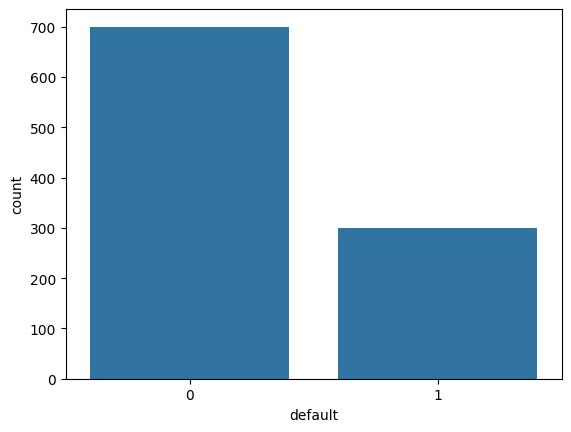

In [56]:
sns.countplot(x='default', data=df)
plt.show()

## Feature Engineering

In [58]:
le = LabelEncoder()

for col in df.select_dtypes(include='object'):
    df[col] = le.fit_transform(df[col])

## Train-Test Split

In [59]:
X = df.drop('default', axis=1)
y = df['default']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Feature Scaling

In [60]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Logistic Regression

In [61]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

pred_prob_lr = lr.predict_proba(X_test)[:,1]

## Model Evaluation (AUC & Gini)

In [62]:
auc_lr = roc_auc_score(y_test, pred_prob_lr)
gini_lr = 2 * auc_lr - 1

print("AUC:", auc_lr)
print("Gini:", gini_lr)

AUC: 0.7242457026084865
Gini: 0.44849140521697306


## Random Forest (Improve Benchmark)

In [63]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

pred_prob_rf = rf.predict_proba(X_test)[:,1]

auc_rf = roc_auc_score(y_test, pred_prob_rf)
gini_rf = 2 * auc_rf - 1

print("Random Forest Gini:", gini_rf)

Random Forest Gini: 0.6256761630003607


## Confusion Matrix

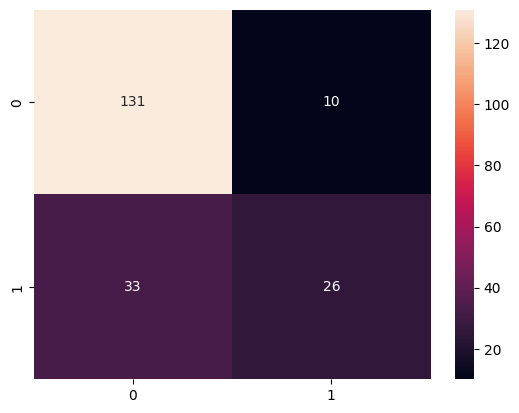

In [64]:
pred_class = rf.predict(X_test)

cm = confusion_matrix(y_test, pred_class)
sns.heatmap(cm, annot=True, fmt='d')
plt.show()

## Feature Importance

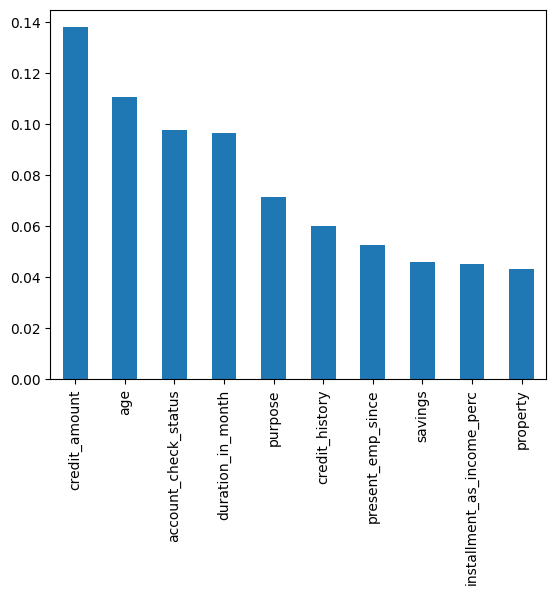

In [65]:
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(10).plot(kind='bar')
plt.show()

## Model Conclusion

## Results

- Benchmark Gini: 0.379
- Logistic Regression Gini: 0.448
- Random Forest Gini: 0.626

Random Forest improves prediction performance and helps identify risky customers early.

As summarized previously, the Random Forest model offers improved prediction performance compared to Logistic Regression, making it more effective for identifying risky customers early.

In [66]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

pred_prob_rf = rf.predict_proba(X_test)[:,1]

auc_rf = roc_auc_score(y_test, pred_prob_rf)
gini_rf = 2 * auc_rf - 1

print("Random Forest Gini:", gini_rf)

Random Forest Gini: 0.6256761630003607
